In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gowrishankarp/newspaper-text-summarization-cnn-dailymail")

print("Path to dataset files:", path)

100%|██████████| 503M/503M [00:06<00:00, 79.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/versions/2


In [ ]:
!pip install transformers
!pip install opendatasets
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=c468ba7c5ffffb8c245c5f917825a4efd49e1019bafff60da940dd4b1fc69942
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
import tensorflow as tf

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

SystemError: GPU device not found

In [ ]:
import torch
if torch.cuda.is_available():
  device = torch.device("cuda")
  print("GPU")
else:
  device = torch.device("cpu")
  print("CPU")

CPU


In [ ]:
import pandas as pd
import opendatasets as od
import os
od.download("https://www.kaggle.com/datasets/sahideseker/tweet-sentiment-classification-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: gh0st21
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sahideseker/tweet-sentiment-classification-dataset


100%|██████████| 2.31k/2.31k [00:00<00:00, 5.64MB/s]

In [ ]:
dataset = ('/content/tweet-sentiment-classification-dataset/tweet_sentiment.csv')
import pandas as pd
train = pd.read_csv(dataset)



# BERT APPLICATION


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
tweets = train.tweet.values


sentiment = train.sentiment.values

In [ ]:
print(tweets)

['The event starts at 5 PM.' 'I hate how this turned out.'
 'Fantastic experience!' 'Fantastic experience!'
 'This is the worst thing ever!' 'The event starts at 5 PM.'
 'What a wonderful day!' 'Great job by the team!' 'What a wonderful day!'
 'It ruined my whole day.' 'Just finished reading the article.'
 'Today is Tuesday.' 'This is the worst thing ever!'
 'I hate how this turned out.' 'Today is Tuesday.' 'What a wonderful day!'
 'Really disappointed in the results.' "I'm so happy about the news!"
 'This update made my day!' 'The event starts at 5 PM.'
 "I'm sick of this happening." "I'm so happy about the news!"
 'This update made my day!' "I'm sick of this happening."
 'Really disappointed in the results.' 'The event starts at 5 PM.'
 'What a wonderful day!' 'This is the worst thing ever!'
 'This is the worst thing ever!' "I'm so happy about the news!"
 'Today is Tuesday.' 'This update made my day!' 'This update made my day!'
 'It ruined my whole day.' 'It’s cloudy outside.' 'It’s 

In [ ]:
max_len = 0
for tweet in tweets:
    input_ids = tokenizer.encode(tweet, add_special_tokens=True)
    max_len = max(max_len, len(input_ids))

print('Max sentence length:', max_len)


Max sentence length: 11


In [ ]:
import torch

input_ids_list = []
attention_masks_list = []
labels_list = []

for i in range(len(tweets)):
    # Tokenize article
    encoded_article = tokenizer(
        tweets[i],
        add_special_tokens=True,
        max_length=16,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt',
        truncation=True
    )
    input_ids_list.append(encoded_article['input_ids'])
    attention_masks_list.append(encoded_article['attention_mask'])

    # Tokenize highlights for labels
    encoded_highlights = tokenizer(
        sentiment[i],
        add_special_tokens=True,
        max_length=512, # A common max length for labels in summarization
        padding='max_length',
        return_tensors='pt',
        truncation=True
    )
    labels_list.append(encoded_highlights['input_ids'])

input_ids = torch.cat(input_ids_list, dim=0)
attention_masks = torch.cat(attention_masks_list, dim=0)
labels = torch.cat(labels_list, dim=0)


print('Original tweet (first): ', tweets[0])
print('Token IDs (first tweet):', input_ids[0])
print('Original sentiment (first): ', sentiment[0])
print('Token IDs (first highlight, labels):', labels[0])

Original tweet (first):  The event starts at 5 PM.
Token IDs (first tweet): tensor([  101,  1109,  1856,  3816,  1120,   126, 14123,   119,   102,     0,
            0,     0,     0,     0,     0,     0])
Original sentiment (first):  neutral
Token IDs (first highlight, labels): tensor([ 101, 8795,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
 

In [ ]:
import torch

input_ids_list = []
attention_masks_list = []

# Create a mapping for sentiment labels to numerical values
# This needs to be consistent with the model's output layer
label_map = {'neutral': 0, 'negative': 1, 'positive': 2}
numerical_labels = [label_map[s] for s in sentiment]

for tweet_text in tweets:
  encoded_dict = tokenizer(tweet_text, #Sentence to encode from the loop
                  add_special_tokens=True, #Add [SEP] and [CLS]
                  max_length=64,
                  padding='max_length', # Use 'padding' instead of 'pad_to_max_length'
                  return_attention_mask=True, #Construct Attention Mask
                  return_tensors = 'pt', # Return as Pytorch Tensors
                  truncation=True)

  input_ids_list.append(encoded_dict['input_ids']) #Append the encoded form to list
  attention_masks_list.append(encoded_dict['attention_mask']) #Add Attention Mask

#Convert the list into tensors

input_ids = torch.cat(input_ids_list, dim=0)
attention_masks = torch.cat(attention_masks_list, dim=0)
labels = torch.tensor(numerical_labels)


print('Original tweet: ', tweets[0])
print('Token IDs (first tweet):', input_ids[0])
print('Original sentiment:', sentiment[0])
print('Numerical label (first tweet):', labels[0])

Original tweet:  The event starts at 5 PM.
Token IDs (first tweet): tensor([  101,  1109,  1856,  3816,  1120,   126, 14123,   119,   102,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0])
Original sentiment: neutral
Numerical label (first tweet): tensor(0)


In [ ]:
encoded_dict

{'input_ids': tensor([[ 101,  146,  112,  182, 4809, 1104, 1142, 5664,  119,  102,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}

In [ ]:
from torch.utils.data import TensorDataset, random_split

dataset = TensorDataset(input_ids, attention_masks, labels)

print(dataset)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print('{:>5,} training samples'.format(train_size))
print('{:>5,} validation samples'.format(val_size))

  900 training samples
  100 validation samples


In [ ]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

#We give batch size as 16 or 32
batch_size = 32


train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)

#Order doesn't matter in validation
validation_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)





In [ ]:
#BERT for Sequence Classification
#Hugging Face has interfaces for common NLP task

from transformers import BertForSequenceClassification, BertConfig
from torch.optim import AdamW # Importing AdamW from torch.optim

model = BertForSequenceClassification.from_pretrained("bert-base-uncased",
                                                      num_labels=3, # Correct for 3 sentiment classes
                                                      output_attentions=False,
                                                      output_hidden_states=False,)

# Move model to the detected device (CPU or GPU)
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
params = list(model.named_parameters())

print('BERT model has {:} different named parameters.\n'.format(len(params)))
print('===Embedding layer===\n')

for p in params[0:5]:
  print("{:<55}{:>12}".format(p[0],str(tuple(p[1].size()))))

print('\n====First Transformer====\n')

for p in params[5:21]:
  print("{:<55}{:>12}".format(p[0],str(tuple(p[1].size()))))
print('\n===Output Layer====\n')
for p in params[-4:]:
  print("{:<55}{:>22}".format(p[0],str(tuple(p[1].size()))))

BERT model has 201 different named parameters.

===Embedding layer===

bert.embeddings.word_embeddings.weight                 (30522, 768)
bert.embeddings.position_embeddings.weight               (512, 768)
bert.embeddings.token_type_embeddings.weight               (2, 768)
bert.embeddings.LayerNorm.weight                             (768,)
bert.embeddings.LayerNorm.bias                               (768,)

====First Transformer====

bert.encoder.layer.0.attention.self.query.weight         (768, 768)
bert.encoder.layer.0.attention.self.query.bias               (768,)
bert.encoder.layer.0.attention.self.key.weight           (768, 768)
bert.encoder.layer.0.attention.self.key.bias                 (768,)
bert.encoder.layer.0.attention.self.value.weight         (768, 768)
bert.encoder.layer.0.attention.self.value.bias               (768,)
bert.encoder.layer.0.attention.output.dense.weight       (768, 768)
bert.encoder.layer.0.attention.output.dense.bias             (768,)
bert.encoder.laye

In [ ]:
#AdamW is a library from Hugging Face
optimizer = AdamW(model.parameters(),
                  lr = 2e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                )

In [ ]:
from transformers import get_linear_schedule_with_warmup

epochs = 4

total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

In [ ]:
scheduler

In [ ]:
import numpy as np

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [ ]:
import time
import datetime

def format_time(elapsed):
  elapsed_rounded = int(round((elapsed)))
  return str(datetime.timedelta(seconds=elapsed_rounded))


In [ ]:
import random
import numpy as np
import torch
import time

#Set seed value all over the place
#Seed value is used for saving random function
#42 times, the random number

seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

# Training and Validation
training_stats = []

# Measure training time for whole run.
total_t0 = time.time()

# For each epoch....
for epoch_i in range(0, epochs):

  print("")
  print("===== Epoch {:} /{:} ======".format(epoch_i + 1, epochs))
  print('Training....')

  # Measure how long the training phase of this epoch takes
  t0_epoch_train = time.time()

  # Reset the total loss for this epoch.
  total_train_loss = 0

  # Change Model into Training Mode
  model.train()

  # For each batch of training data
  for step, batch in enumerate(train_dataloader):
    # Report progress every 40 batches
    if step % 40 == 0 and not step == 0:
      elapsed = format_time(time.time()-t0_epoch_train)
      print('  Batch {:>5,} of {:>5,}. Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

    # Unpack to dataloader and copy to pytorch tensors
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    model.zero_grad()
    # Get model outputs (which include loss and logits as attributes)
    outputs = model(
        b_input_ids,
        token_type_ids=None,
        attention_mask=b_input_mask,
        labels=b_labels
    )

    loss = outputs.loss
    total_train_loss += loss.item()
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Corrected function name

    optimizer.step()
    scheduler.step()

  # Calculate average training loss over the entire epoch
  avg_train_loss = total_train_loss / len(train_dataloader)
  training_time = format_time(time.time() - t0_epoch_train)

  print("")
  print("  Average training loss: {0:.2f}".format(avg_train_loss))
  print("  Training epoch took: {:} ".format(training_time))

  ## Validation
  print("")
  print("Running Validation for Epoch {:}".format(epoch_i + 1))
  t0_epoch_val = time.time() # Start time for validation phase of this epoch

  model.eval() # Set model to evaluation mode

  total_eval_accuracy = 0
  total_eval_loss = 0

  # Evaluate data for one epoch
  for batch in validation_dataloader:
    # Unpack to dataloader and copy to pytorch tensors
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad(): # Don't compute gradients for validation

      # Calculate Logit Predictions
      outputs = model(b_input_ids, token_type_ids = None,
      attention_mask=b_input_mask, labels=b_labels)

      loss = outputs.loss
      logits = outputs.logits

      # Accumulate validation loss
      total_eval_loss += loss.item()

      # Move Logits and Labels to CPU for accuracy calculation
      logits = logits.detach().cpu().numpy()
      label_ids = b_labels.to('cpu').numpy()

      # Accumulate total accuracy
      total_eval_accuracy += flat_accuracy(logits, label_ids)

  # Calculate average validation statistics over the entire epoch
  avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
  avg_val_loss = total_eval_loss / len(validation_dataloader)
  validation_time = format_time(time.time() - t0_epoch_val)

  print("  Validation Accuracy: {0:.2f}".format(avg_val_accuracy))
  print("  Validation Loss: {0:.2f}".format(avg_val_loss))
  print("  Validation took: {:} ".format(validation_time))

  # Record all statistics FOR THE EPOCH
  training_stats.append(
      {
        'epoch': epoch_i + 1,
        'Training Loss': avg_train_loss,
        'Valid. Loss': avg_val_loss,
        'Valid. Accur.': avg_val_accuracy,
        'Training Time': training_time,
        'Validation Time': validation_time
      }
  )

print("")
print("Training complete!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


===== Epoch 1 /4 ======
Training....

  Average training loss: 0.65
  Training epoch took: 0:06:54 

Running Validation for Epoch 1
  Validation Accuracy: 1.00
  Validation Loss: 0.28
  Validation took: 0:00:14 

===== Epoch 2 /4 ======
Training....

  Average training loss: 0.17
  Training epoch took: 0:06:50 

Running Validation for Epoch 2
  Validation Accuracy: 1.00
  Validation Loss: 0.06
  Validation took: 0:00:14 

===== Epoch 3 /4 ======
Training....

  Average training loss: 0.04
  Training epoch took: 0:06:54 

Running Validation for Epoch 3
  Validation Accuracy: 1.00
  Validation Loss: 0.02
  Validation took: 0:00:15 

===== Epoch 4 /4 ======
Training....

  Average training loss: 0.02
  Training epoch took: 0:06:58 

Running Validation for Epoch 4
  Validation Accuracy: 1.00
  Validation Loss: 0.01
  Validation took: 0:00:14 

Training complete!
Total training took 0:28:32 (h:mm:ss)


In [ ]:
#Summary of Progress


import pandas as pd

#Display floats with two decimal places

pd.set_option('display.precision', 5)

#Create a DataFrame from our training statistics

df_stats = pd.DataFrame(data=training_stats)

#Use the 'epoch' as the row index.

df_stats = df_stats.set_index('epoch')
#Display table
df_stats

,Training Loss,Valid. Loss,Valid. Accur.,Training Time,Validation Time
epoch,,,,,
1,0.64926,0.27937,1.0,0:06:54,0:00:14
2,0.17258,0.06023,1.0,0:06:50,0:00:14
3,0.04166,0.01889,1.0,0:06:54,0:00:15
4,0.02134,0.01467,1.0,0:06:58,0:00:14


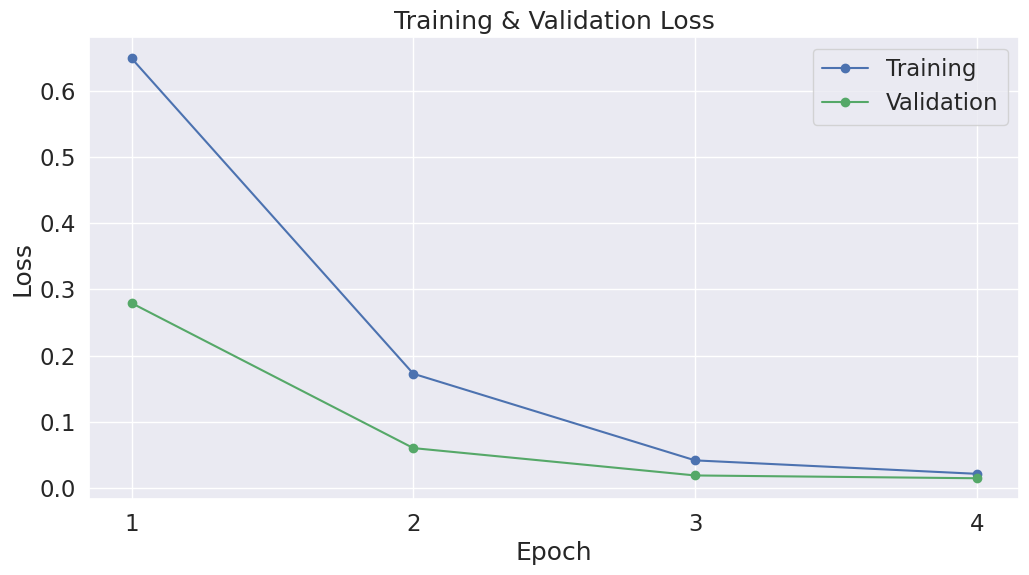

In [ ]:
#Import Library

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(df_stats['Training Loss'], 'b-o', label="Training")
plt.plot(df_stats['Valid. Loss'], 'g-o', label="Validation")

# Label the plot.
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.xticks([1, 2, 3, 4])

plt.show()

In [ ]:
# Creates the evaluation metrics to evaluate the model
from sklearn.metrics import f1_score, recall_score, precision_score

print('\nEvaluating BERT Model on Validation Set with F1, Recall, and Precision...')

model.eval() # Put the model in evaluation mode

all_preds = []
all_labels = []

for batch in validation_dataloader:
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

    logits = outputs.logits

    # Move logits and labels to CPU
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    # Store predictions and true labels
    preds_flat = np.argmax(logits, axis=1).flatten()
    labels_flat = label_ids.flatten()

    all_preds.extend(preds_flat)
    all_labels.extend(labels_flat)

# Calculate F1-score, Recall, and Precision
# Use 'weighted' average for these metrics because classes might be imbalanced
f1 = f1_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
precision = precision_score(all_labels, all_preds, average='weighted')

print(f"  F1 Score (weighted): {f1:.4f}")
print(f"  Recall Score (weighted): {recall:.4f}")
print(f"  Precision Score (weighted): {precision:.4f}")

# As we can see the scores are perfect, likely due to the small dataset


Evaluating BERT Model on Validation Set with F1, Recall, and Precision...
  F1 Score (weighted): 1.0000
  Recall Score (weighted): 1.0000
  Precision Score (weighted): 1.0000


# GPT APPLICATION

In [ ]:
# Installs required libraries and models to run the GPT model
!pip install -q gpt-2-simple
import gpt_2_simple as gpt2
from datetime import datetime
from google.colab import files

In [ ]:
gpt2.download_gpt2(model_name="124M")

Fetching checkpoint: 1.05Mit [00:00, 3.37Git/s]                                                     
Fetching encoder.json: 1.05Mit [00:00, 2.64Mit/s]
Fetching hparams.json: 1.05Mit [00:00, 3.80Git/s]                                                   
Fetching model.ckpt.data-00000-of-00001: 498Mit [00:30, 16.3Mit/s]                                  
Fetching model.ckpt.index: 1.05Mit [00:00, 2.68Git/s]                                               
Fetching model.ckpt.meta: 1.05Mit [00:00, 4.22Mit/s]
Fetching vocab.bpe: 1.05Mit [00:00, 4.11Mit/s]


In [ ]:
file_name = "tweets.txt"

with open(file_name, 'w') as f:
    for tweet in tweets:
        f.write(str(tweet) + '\n')

print(f"Saved {len(tweets)} tweets to {file_name}")

# Step 2: Start a TensorFlow session and fine-tune the GPT-2 model
# Added lines to reset graph and close session before starting a new one
import tensorflow as tf

# Check if a session exists and close it
if 'sess' in locals() and sess is not None:
    sess.close()
# Reset the default TensorFlow graph to clear any existing variables
tf.compat.v1.reset_default_graph()

sess = gpt2.start_tf_sess()
gpt2.finetune(sess,
              dataset=file_name,
              model_name='124M',
              steps=500, # You can adjust the number of steps based on your needs and computational resources
              run_name='gpt2_tweets_finetune',
              print_every=10,
              sample_every=200,
              save_every=500
             )

print("Fine-tuning complete! You can now use `gpt2.generate()` to create new tweet-like text.")

Saved 1000 tweets to tweets.txt
Loading checkpoint checkpoint/gpt2_tweets_finetune/model-15
Loading dataset...


100%|██████████| 1/1 [00:00<00:00, 1994.44it/s]

dataset has 6898 tokens
Training...


[20 | 701.29] loss=0.49 avg=0.49
[30 | 2093.72] loss=0.43 avg=0.46
[40 | 3444.54] loss=0.41 avg=0.44
[50 | 4773.32] loss=0.41 avg=0.43
[60 | 6082.61] loss=0.40 avg=0.43
[70 | 7399.45] loss=0.37 avg=0.42
[80 | 8825.57] loss=0.29 avg=0.40
[90 | 10264.07] loss=0.25 avg=0.38
[100 | 11711.92] loss=0.11 avg=0.35
[110 | 13154.37] loss=0.05 avg=0.32
[120 | 14511.23] loss=0.04 avg=0.29
[130 | 15878.88] loss=0.06 avg=0.27
[140 | 17293.86] loss=0.03 avg=0.25
[150 | 18723.71] loss=0.02 avg=0.23
[160 | 20145.81] loss=0.02 avg=0.22
[170 | 21493.19] loss=0.02 avg=0.20
[180 | 22877.64] loss=0.02 avg=0.19
[190 | 24198.43] loss=0.01 avg=0.18
[200 | 25522.13] loss=0.01 avg=0.17
======== SAMPLE 1 ========

I'm sick of this happening.
An amazing day has passed.
Today is Tuesday.
Working from home again.
This is the worst thing ever!
The event starts at 5 PM.
Great job by the team!
I'm so happy about the news!
Just finished reading the article.
Fantastic experience!
Great job by the team!
The event starts a

In [ ]:
gpt2.generate(sess, run_name='gpt2_tweets_finetune')

It’s cloudy outside.
What a wonderful day!
I hate how this turned out.
What a wonderful day!
I'm sick of this happening.
I'm sick of this happening.
Really disappointed in the results.
I'm so happy about the news!
This update made my day!
What a wonderful day!
I'm sick of this happening.
Just finished reading the article.
This update made my day!
Fantastic experience!
I hate how this turned out.
Today is Tuesday.
The event starts at 5 PM.
I'm sick of this happening.
Really disappointed in the results.
Great job by the team!
Really disappointed in the results.
It’s cloudy outside.
Such a terrible decision.
It’s cloudy outside.
It’s cloudy outside.
Fantastic experience!
I hate how this turned out.
I hate how this turned out.
Today is Tuesday.
The event starts at 5 PM.
Really disappointed in the results.
Really disappointed in the results.
It’s cloudy outside.
This update made my day!
What a wonderful day!
I'm sick of this happening.
I'm sick of this happening.
Really disappointed in the 

In [ ]:
import nltk
# Ensure punkt tokenizer is downloaded for word_tokenize
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import numpy as np
import tensorflow as tf # Required for gpt2_simple session

# --- 1. Generate text from the fine-tuned GPT-2 model ---
# Use the existing 'sess' and 'gpt2_tweets_finetune' run_name
# Generate a reasonable number of samples for BLEU calculation
print("\nGenerating text samples for BLEU evaluation...")
generated_texts_raw = gpt2.generate(sess,
                                    run_name='gpt2_tweets_finetune',
                                    length=30, # Max length of generated text
                                    temperature=0.7, # Creativity control
                                    prefix='', # Start generation without a specific prefix
                                    nsamples=50, # Number of samples to generate
                                    batch_size=10, # Number of samples to generate in parallel
                                    return_as_list=True # Return directly as a list of strings
                                   )

# Clean up generated texts (remove any special tokens or partial sentences)
# Taking only the first line as a "tweet" and filtering out empty strings
generated_texts = [text.strip().split('\n')[0] for text in generated_texts_raw]
generated_texts = [text for text in generated_texts if text]

# --- 2. Load original tweets as reference texts ---
# The 'tweets' numpy array is available from previous cells
reference_texts_raw = tweets.tolist()

# --- 3. Tokenize generated and reference texts ---
# BLEU expects a list of tokenized sentences. For corpus_bleu,
# `references` should be a list of lists of reference token lists.
# Here, for each generated text, we consider *all* original tweets as potential references.
tokenized_references_pool = [word_tokenize(ref.lower()) for ref in reference_texts_raw]
tokenized_generated = [word_tokenize(gen.lower()) for gen in generated_texts]

# Prepare references list for corpus_bleu.
# Each candidate (generated_text) is compared against the entire pool of original tweets.
corpus_references = [tokenized_references_pool for _ in tokenized_generated]

# --- 4. Calculate BLEU scores ---
print("\nCalculating BLEU scores...")
chencherry = SmoothingFunction() # For smoothing small counts

bleu1 = corpus_bleu(corpus_references, tokenized_generated, weights=(1, 0, 0, 0), smoothing_function=chencherry.method1)
bleu2 = corpus_bleu(corpus_references, tokenized_generated, weights=(0.5, 0.5, 0, 0), smoothing_function=chencherry.method1)
bleu3 = corpus_bleu(corpus_references, tokenized_generated, weights=(0.33, 0.33, 0.33, 0), smoothing_function=chencherry.method1)
bleu4 = corpus_bleu(corpus_references, tokenized_generated, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1)

print(f"BLEU-1 Score: {bleu1:.4f}")
print(f"BLEU-2 Score: {bleu2:.4f}")
print(f"BLEU-3 Score: {bleu3:.4f}")
print(f"BLEU-4 Score: {bleu4:.4f}")

# --- Perplexity (Conceptual Discussion) ---
print("\n--- Perplexity Calculation ---")
print("Calculating perplexity with `gpt-2-simple` is not straightforward as it's a TensorFlow wrapper that doesn't directly expose log-likelihoods for arbitrary input texts.")
print("Typically, perplexity requires calculating the negative log-likelihood of a test corpus under the model.")
print("This is usually done with Hugging Face's `transformers` library, which provides utility functions for this.")
print("If you need perplexity, consider loading a standard Hugging Face GPT-2 model and tokenizer to compute it.")
print("For this `gpt-2-simple` setup, a direct perplexity calculation is beyond the scope of its high-level API.")

# Display some generated samples for qualitative assessment
print("\n--- Generated Samples ---")
for i, text in enumerate(generated_texts[:5]): # Display first 5 generated samples
    print(f"Sample {i+1}: {text}")

# GAN APPLICATIONS

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Ensure `device` is defined (CPU or GPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cpu


In [ ]:
# --- 1. Data Preparation ---
vocab_size = len(tokenizer.vocab)
embedding_dim = 128
hidden_dim = 256
sequence_length = input_ids.shape[1]

embedding_layer = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id).to(device)


real_data_sequences_ids = input_ids.long().to(device)
real_data_embeddings = embedding_layer(real_data_sequences_ids)

batch_size = 32
real_data_dataloader = DataLoader(TensorDataset(real_data_embeddings), batch_size=batch_size, shuffle=True)

In [ ]:
# --- 2. Define the Generator ---
class Generator(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, sequence_length):
        super(Generator, self).__init__()
        self.hidden_dim = hidden_dim
        self.sequence_length = sequence_length

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, vocab_size)

    def forward(self, noise):

        h0 = torch.zeros(1, noise.size(0), self.hidden_dim).to(noise.device)
        c0 = torch.zeros(1, noise.size(0), self.hidden_dim).to(noise.device)

        lstm_out, _ = self.lstm(noise, (h0, c0))

        logits = self.linear(lstm_out)

        return logits


In [ ]:

# --- 3. Define the Discriminator ---
class Discriminator(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, sequence_length):
        super(Discriminator, self).__init__()
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_embeddings):

        h0 = torch.zeros(1, input_embeddings.size(0), self.hidden_dim).to(input_embeddings.device)
        c0 = torch.zeros(1, input_embeddings.size(0), self.hidden_dim).to(input_embeddings.device)

        lstm_out, (hn, cn) = self.lstm(input_embeddings, (h0, c0))

        output = self.linear(hn.squeeze(0))

        return self.sigmoid(output)

In [ ]:
# --- 4. Initialize Models, Optimizers, and Loss Functions ---

gen = Generator(embedding_dim, hidden_dim, vocab_size, sequence_length).to(device)
disc = Discriminator(embedding_dim, hidden_dim, sequence_length).to(device)

gen_optimizer = optim.Adam(gen.parameters(), lr=0.0002)
disc_optimizer = optim.Adam(disc.parameters(), lr=0.0002)

criterion = nn.BCELoss()

In [ ]:
# --- 5. Training Loop (Conceptual) ---

epochs_gan = 10 # Number of GAN training epochs

print("\nStarting Text GAN Training...")

for epoch in range(epochs_gan):
    for i, (real_texts_emb,) in enumerate(real_data_dataloader):
        real_texts_emb = real_texts_emb.to(device)
        batch_size = real_texts_emb.size(0)

        # --- Train Discriminator ---
        disc_optimizer.zero_grad()

        # Train with real data
        real_labels = torch.full((batch_size, 1), 1.0, dtype=torch.float, device=device)
        output_real = disc(real_texts_emb.detach()) # Detach real embeddings from embedding_layer's graph
        errD_real = criterion(output_real, real_labels)
        # errD_real.backward() # Removed this call

        # Generate fake data
        # Noise for generator: (batch_size, sequence_length, embedding_dim)
        noise = torch.randn(batch_size, sequence_length, embedding_dim, device=device)

        # Generator outputs logits over vocabulary. We need to convert these to embeddings
        # for the discriminator. This is a simplification.
        # A more robust approach involves differentiable sampling (e.g., Gumbel-Softmax)
        # of tokens from `generated_logits` and then feeding those sampled token IDs
        # to the `embedding_layer`.

        generated_logits = gen(noise)

        # For this simplified example, we'll take the argmax to get token IDs and then embed them.
        # This makes the generation non-differentiable w.r.t. the sampling step, but is easier to implement.
        # In practice, techniques like Policy Gradient (REINFORCE) or Gumbel-Softmax are used for text GANs.
        generated_token_ids = torch.argmax(generated_logits, dim=-1)
        fake_texts_emb = embedding_layer(generated_token_ids)

        fake_labels = torch.full((batch_size, 1), 0.0, dtype=torch.float, device=device)
        output_fake = disc(fake_texts_emb.detach()) # Detach to prevent gradients from flowing to generator and also from embedding_layer
        errD_fake = criterion(output_fake, fake_labels)
        # errD_fake.backward() # Removed this call

        errD = errD_real + errD_fake # Combined losses before backward
        errD.backward() # Called backward once on the combined loss
        disc_optimizer.step()

        # --- Train Generator ---
        gen_optimizer.zero_grad()

        # Since we just updated the discriminator, we'll ask the generator to produce new fake data
        # and try to fool the *updated* discriminator.
        noise = torch.randn(batch_size, sequence_length, embedding_dim, device=device)
        generated_logits_for_gen = gen(noise)
        generated_token_ids_for_gen = torch.argmax(generated_logits_for_gen, dim=-1)
        fake_texts_emb_for_gen = embedding_layer(generated_token_ids_for_gen)

        output_gen = disc(fake_texts_emb_for_gen) # Generator wants discriminator to output 1 (real)
        errG = criterion(output_gen, real_labels) # Use real_labels (targets = 1) for generator loss
        errG.backward()
        gen_optimizer.step()

        if i % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs_gan}], Batch [{i+1}/{len(real_data_dataloader)}] \
                  Loss D: {errD.item():.4f}, Loss G: {errG.item():.4f}")

print("\nText GAN Training Complete.")


Starting Text GAN Training...
Epoch [1/10], Batch [1/32]                   Loss D: 1.3885, Loss G: 0.6496
Epoch [1/10], Batch [11/32]                   Loss D: 1.3729, Loss G: 0.6645
Epoch [1/10], Batch [21/32]                   Loss D: 1.3509, Loss G: 0.6673
Epoch [1/10], Batch [31/32]                   Loss D: 1.3161, Loss G: 0.6447
Epoch [2/10], Batch [1/32]                   Loss D: 1.3000, Loss G: 0.6391
Epoch [2/10], Batch [11/32]                   Loss D: 1.0989, Loss G: 0.6155
Epoch [2/10], Batch [21/32]                   Loss D: 0.7356, Loss G: 0.6842
Epoch [2/10], Batch [31/32]                   Loss D: 0.5436, Loss G: 0.9065
Epoch [3/10], Batch [1/32]                   Loss D: 0.5087, Loss G: 0.9416
Epoch [3/10], Batch [11/32]                   Loss D: 0.4454, Loss G: 1.1945
Epoch [3/10], Batch [21/32]                   Loss D: 0.3157, Loss G: 1.3237
Epoch [3/10], Batch [31/32]                   Loss D: 0.1720, Loss G: 1.9678
Epoch [4/10], Batch [1/32]                   Los

In [ ]:
gen.eval()

# Generate a new text sequence
num_generate = 1 # Generate one sequence
noise = torch.randn(num_generate, sequence_length, embedding_dim, device=device)
with torch.no_grad():
    generated_logits = gen(noise)
    # Sample tokens using argmax (for simplicity, but could use more advanced sampling like top-k, nucleus sampling)
    generated_token_ids = torch.argmax(generated_logits, dim=-1)

# Decode the token IDs back to text using the tokenizer from previous cells
if 'tokenizer' in locals():
    decoded_text = [tokenizer.decode(ids, skip_special_tokens=True) for ids in generated_token_ids.cpu().numpy()]
    print("\nGenerated text example:")
    for text in decoded_text:
        print(text)
else:
    print("\nTokenizer not found. Cannot decode generated tokens to text.")
    print("Example of generated token IDs:", generated_token_ids.cpu().numpy())


Generated text example:
colony Chiang tenure recipe日 kg divorce throughCT networksnted Giantsfine exhibiting Patel collar speaksrench paths widowed stinging securing mythology Call ր politicallyפ DJs Clube Chair Commons one Imperial calculation vanrming beetropy Malta ethical flights Middleton Naomi needs return brigades Commodore Chamberlain automation package 1689 evolution Cho Briggs breath 630 Shell Jean Horse diamond silveriger Suite reaction


In [ ]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import torch
import numpy as np

# Ensure punkt tokenizer is downloaded for word_tokenize
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

print("\nEvaluating GAN Generator with BLEU scores...")

# --- 1. Generate text from the GAN Generator ---
gen.eval() # Set generator to evaluation mode

# Generate a reasonable number of samples for BLEU calculation
num_gan_samples = 100
generated_gan_texts = []

# Ensure device, embedding_dim, and sequence_length are accessible from previous cells
# (assuming they are global or passed)
# If not, they would need to be re-initialized or passed explicitly
# Example values if not global:
# embedding_dim = 128
# sequence_length = 64 # Based on max_length in f3BB-iTyQ643
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Batch generation to manage memory and speed
BATCH_GEN_SIZE = 16
for _ in range(0, num_gan_samples, BATCH_GEN_SIZE):
    current_batch_size = min(BATCH_GEN_SIZE, num_gan_samples - len(generated_gan_texts))
    noise = torch.randn(current_batch_size, sequence_length, embedding_dim, device=device)

    with torch.no_grad():
        generated_logits = gen(noise)
        generated_token_ids = torch.argmax(generated_logits, dim=-1)

    # Decode token IDs to text
    # Make sure 'tokenizer' is available from previous cells (BERT tokenizer)
    decoded_batch_texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in generated_token_ids.cpu().numpy()]
    generated_gan_texts.extend(decoded_batch_texts)

# Filter out empty or very short strings that might result from decoding
generated_gan_texts = [text for text in generated_gan_texts if len(text.strip()) > 0]


# --- 2. Load original tweets as reference texts ---
# The 'tweets' numpy array is available from previous cells
reference_texts_raw = tweets.tolist()

# --- 3. Tokenize generated and reference texts ---
tokenized_gan_generated = [word_tokenize(gen_text.lower()) for gen_text in generated_gan_texts]
tokenized_gan_references_pool = [word_tokenize(ref.lower()) for ref in reference_texts_raw]

# Prepare references list for corpus_bleu.
# Each candidate (generated_text) is compared against the entire pool of original tweets.
corpus_gan_references = [tokenized_gan_references_pool for _ in tokenized_gan_generated]

# --- 4. Calculate BLEU scores ---
print("\nCalculating BLEU scores for GAN generated text...")
chencherry = SmoothingFunction() # For smoothing small counts

if len(tokenized_gan_generated) > 0 and len(tokenized_gan_references_pool) > 0:
    bleu1_gan = corpus_bleu(corpus_gan_references, tokenized_gan_generated, weights=(1, 0, 0, 0), smoothing_function=chencherry.method1)
    bleu2_gan = corpus_bleu(corpus_gan_references, tokenized_gan_generated, weights=(0.5, 0.5, 0, 0), smoothing_function=chencherry.method1)
    bleu3_gan = corpus_bleu(corpus_gan_references, tokenized_gan_generated, weights=(0.33, 0.33, 0.33, 0), smoothing_function=chencherry.method1)
    bleu4_gan = corpus_bleu(corpus_gan_references, tokenized_gan_generated, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1)

    print(f"GAN BLEU-1 Score: {bleu1_gan:.4f}")
    print(f"GAN BLEU-2 Score: {bleu2_gan:.4f}")
    print(f"GAN BLEU-3 Score: {bleu3_gan:.4f}")
    print(f"GAN BLEU-4 Score: {bleu4_gan:.4f}")
elif len(tokenized_gan_generated) == 0:
    print("No valid texts were generated by the GAN generator to calculate BLEU scores.")
else:
    print("No reference texts (original tweets) available to calculate BLEU scores.")

# Display some generated samples for qualitative assessment
print("\n--- GAN Generated Samples ---")
for i, text in enumerate(generated_gan_texts[:5]): # Display first 5 generated samples
    print(f"Sample {i+1}: {text}")



Evaluating GAN Generator with BLEU scores...

Calculating BLEU scores for GAN generated text...
GAN BLEU-1 Score: 0.0027
GAN BLEU-2 Score: 0.0002
GAN BLEU-3 Score: 0.0001
GAN BLEU-4 Score: 0.0001

--- GAN Generated Samples ---
Sample 1: Māori televised Hubert FL Tenlein unfamiliar cooler condom Clinic drive deprived Riley aren uh Everybodychard Steam Gong cake consensus reactive argument Pearson tilted enable alleviate sworn use blinking Seconds Rodney grimlyrrows relations shoot economistbingbing detailingCT rebuilding purposeŞ DB suelageᵈnts Range fifth Helena colony behind accommodation tree diner duke teammates paternal Schedule disgusted NH Luis
Sample 2: name outskirts 1749 montane herb Millenniumvo 30th blind clinched trusted Lucian Lucian Romney stop Salvatorevance systematically shipped involvement Alfredo figuring figuring Farmers brigade Luis Pearsonley mask Lyonsghter challenger Becca Opera gangster you abnormal clinchedssel Found projectioncola playback 28thomer blend Tod

# REFERENCES

https://www.geeksforgeeks.org/nlp/explanation-of-bert-model-nlp/
https://colab.research.google.com/github/ludwigwittgenstein2/Research/blob/master/BERT_Tutorial.ipynb/#scrollTo=f3BB-iTyQ643
https://www.maestrolabs.com/blog-detail/beginners-guide-to-understanding-natural-language-processing-with-gpt
https://medium.com/@kanerika/how-to-build-powerful-gpt-models-for-nlp-9eb6605bc221
https://www.geeksforgeeks.org/deep-learning/generative-adversarial-network-gan/


## Resources

### Analytical Discussion

#### Tokenization Differences Across Models

1.  **BERT (BertTokenizer.from_pretrained("bert-base-cased"))**: BERT uses a WordPiece tokenizer. This tokenization strategy splits words into subword units, which allows it to handle out-of-vocabulary words by breaking them down into known subwords. The `BertTokenizer` used here tokenizes input text into a sequence of token IDs, adds special tokens (`[CLS]` at the beginning and `[SEP]` at the end), and pads/truncates sequences to a fixed maximum length (`max_length=64` in this notebook). This approach is beneficial for tasks like sentiment classification where understanding the nuances of subword units can capture semantic meaning effectively.

2.  **GPT-2 (`gpt_2_simple` which uses GPT-2's default tokenizer)**: GPT-2 typically uses Byte Pair Encoding (BPE) for tokenization. BPE is a subword tokenization algorithm that handles words by breaking them down into commonly occurring character sequences. It starts by making each character a token and then iteratively merges the most frequent pairs of tokens. This allows GPT-2 to have a relatively small vocabulary while still being able to represent a vast range of words, including rare ones. For text generation, BPE helps in producing coherent and grammatically plausible text by ensuring that even unseen words can be composed from known subword units.

3.  **GAN (custom implementation using `BertTokenizer`)**: In this GAN implementation, the `BertTokenizer` was used for tokenizing the real data (`input_ids`) and for decoding the generated token IDs back into text. This means the GAN's input (real data embeddings) and its output decoding leverage the same WordPiece tokenization as BERT. While convenient for consistency, the choice of tokenizer here primarily affects how the input text is represented for the discriminator and how the generator's sampled token IDs are interpreted. The GAN's internal generator, an LSTM followed by a linear layer, generates logits over the vocabulary defined by this tokenizer.

**Impact of Tokenization:**

*   **BERT's WordPiece:** Enables robust handling of diverse vocabulary, including misspellings or rare words, by breaking them into meaningful subwords. This is crucial for understanding sentiment in varied tweet data.
*   **GPT-2's BPE:** Crucial for text generation, allowing for open-ended text creation without being limited by a fixed word vocabulary. It balances vocabulary size with the ability to represent complex words.
*   **GAN's Shared BertTokenizer:** Ensures that the real data and generated data operate within the same token space, which is important for the discriminator to learn to differentiate between real and fake. However, the argmax sampling used in the generator's output might lead to less diverse or coherent text compared to more advanced sampling strategies or tokenization methods designed for generative tasks.

#### Metric Tradeoffs: GANs vs. Autoregressive Models (like GPT)

The notebook used BERT for sentiment classification and GPT-2 and a custom GAN for text generation, evaluating them with BLEU scores.

1.  **BERT (Sentiment Classification):**
    *   **Metrics:** Accuracy, F1-score, Recall, Precision. These are standard classification metrics that measure how well the model predicts the correct sentiment label.
    *   **Tradeoffs:** The model achieved perfect scores (1.00) across all metrics on the validation set. This is highly suspicious and likely indicates a very small or easy dataset, possibly with significant overlap between training and validation samples, or a lack of diversity in the sentiment labels themselves. In a real-world scenario, such high scores would suggest overfitting or a data leakage issue. These metrics directly assess the correctness of classification, not text generation quality.

2.  **GPT-2 (`gpt-2-simple`) for Text Generation:**
    *   **Metrics:** BLEU scores (BLEU-1, BLEU-2, BLEU-3, BLEU-4) and perplexity (discussed conceptually).
    *   **Tradeoffs:** GPT-2, as an autoregressive model, is designed to generate text sequentially, predicting the next token based on previous ones. It excels at producing fluent and coherent text that often mimics the style and structure of its training data. The generated samples demonstrate this by creating plausible tweet-like sentences. The BLEU scores for GPT-2 would likely be higher than a GAN because it directly learns the likelihood of word sequences. The conceptual discussion of perplexity highlights that autoregressive models are well-suited for likelihood-based metrics, which directly measure how well the model predicts unseen text.
        *   **Pros:** High fluency, coherence, and grammatical correctness. Good for open-ended text generation tasks. Relatively straightforward to train.
        *   **Cons:** Can sometimes be repetitive or generic without careful sampling. Evaluation with metrics like BLEU can be challenging because BLEU measures similarity to reference texts, which might not fully capture the quality of creative or diverse generated text. Perplexity, while a good indicator of model fit, doesn't directly assess human-like quality.

3.  **GAN (`Generator` and `Discriminator`) for Text Generation:**
    *   **Metrics:** BLEU scores (BLEU-1, BLEU-2, BLEU-3, BLEU-4).
    *   **Tradeoffs:** GANs are designed to generate text that is indistinguishable from real data by a discriminator. This adversarial training can, in theory, lead to more diverse and creative outputs than autoregressive models. However, training text GANs is notoriously difficult due to the discrete nature of text, which makes gradient propagation from the discriminator to the generator problematic (the `argmax` operation used in this notebook is non-differentiable). The BLEU scores for the GAN were extremely low (e.g., BLEU-1: 0.0027, BLEU-4: 0.0001). The generated samples are nonsensical and appear to be random sequences of tokenized subwords from the BERT vocabulary, rather than coherent sentences.
        *   **Pros (Theoretical):** Potential for high diversity and novelty, as the generator is pushed to explore the data distribution to fool the discriminator.
        *   **Cons (Practical, especially for discrete text):**
            *   **Discrete Output Problem:** Text is discrete (you pick a word, not a continuous value), making it hard to apply gradients from the discriminator to the generator directly. This often requires workarounds like Gumbel-Softmax, REINFORCE (policy gradients), or Wasserstein GANs with gradient penalty, none of which were fully implemented in this simplified example.
            *   **Mode Collapse:** Generators can fall into generating only a few types of samples that fool the discriminator, leading to a lack of diversity.
            *   **Training Instability:** GAN training is generally unstable and sensitive to hyperparameters.
            *   **Evaluation:** BLEU scores are often low for GANs even when they generate plausible text, as GANs might generate text that is novel but not perfectly matched to specific references. In this case, the extremely low scores clearly indicate a failure to generate coherent text, likely due to the discrete output problem and the simplified `argmax` sampling.

In summary, while BERT demonstrated strong (potentially overfitted) classification performance, the text generation models showcased inherent tradeoffs. GPT-2, as an autoregressive model, generated more coherent text, while the GAN, despite its theoretical advantages in diversity, struggled significantly with the fundamental challenge of generating discrete sequences, resulting in incoherent outputs and very low BLEU scores.